In [10]:
import pandas as pd 

In [68]:
df = pd.read_csv("Nassau Candy Distributor.csv")


In [12]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,Division,Region,Product ID,Product Name,Sales,Units,Gross Profit,Cost
0,1,US-2021-103800-CHO-MIL-31000,03-01-2024,30-06-2026,Standard Class,103800,United States,Houston,Texas,77095,Chocolate,Interior,CHO-MIL-31000,Wonka Bar - Milk Chocolate,6.50,2,4.22,2.28
1,2,US-2021-112326-CHO-TRI-54000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,7.50,2,4.90,2.60
2,3,US-2021-112326-CHO-NUT-13000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,10.47,3,7.47,3.00
3,4,US-2021-112326-CHO-SCR-58000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,10.80,3,7.50,3.30
4,5,US-2021-141817-CHO-TRI-54000,05-01-2024,05-07-2026,Standard Class,141817,United States,Philadelphia,Pennsylvania,19143,Chocolate,Atlantic,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,11.25,3,7.35,3.90


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          10194 non-null  int64  
 1   Order ID        10194 non-null  object 
 2   Order Date      10194 non-null  object 
 3   Ship Date       10194 non-null  object 
 4   Ship Mode       10194 non-null  object 
 5   Customer ID     10194 non-null  int64  
 6   Country/Region  10194 non-null  object 
 7   City            10194 non-null  object 
 8   State/Province  10194 non-null  object 
 9   Postal Code     10194 non-null  object 
 10  Division        10194 non-null  object 
 11  Region          10194 non-null  object 
 12  Product ID      10194 non-null  object 
 13  Product Name    10194 non-null  object 
 14  Sales           10194 non-null  float64
 15  Units           10194 non-null  int64  
 16  Gross Profit    10194 non-null  float64
 17  Cost            10194 non-null 

In [ ]:
#CLEANING

In [14]:
#Validate cost and sales value

In [15]:
invalid_records = df[(df['Sales'] <= 0) | (df['Cost'] < 0)]

print("Invalid Records:")

print(invalid_records)
df = df[(df['Sales'] > 0) & (df['Cost'] >= 0)]

print(df.shape)

Invalid Records:
Empty DataFrame
Columns: [Row ID, Order ID, Order Date, Ship Date, Ship Mode, Customer ID, Country/Region, City, State/Province, Postal Code, Division, Region, Product ID, Product Name, Sales, Units, Gross Profit, Cost]
Index: []
(10194, 18)


In [16]:
# Find zero sales or negative profit

invalid_profit = df[(df['Sales'] == 0) | (df['Gross Profit'] < 0)]
print("Invalid Profit Records:")
print(invalid_profit)

# Remove them
df = df[(df['Sales'] > 0) & (df['Gross Profit'] >= 0)]

print(df.shape)

Invalid Profit Records:
Empty DataFrame
Columns: [Row ID, Order ID, Order Date, Ship Date, Ship Mode, Customer ID, Country/Region, City, State/Province, Postal Code, Division, Region, Product ID, Product Name, Sales, Units, Gross Profit, Cost]
Index: []
(10194, 18)


In [17]:
# Check missing values
print(df[['Units']].isnull().sum())

Units    0
dtype: int64


In [18]:
# Fill missing Units with median
df['Units'] = df['Units'].fillna(df['Units'].median())

# Verify
print(df['Units'].isnull().sum())

0


In [19]:
# Standardize Product Name
df['Product Name'] = (
    df['Product Name']
    .astype(str)
    .str.strip()
    .str.title()
)

# Standardize Division
df['Division'] = (
    df['Division']
    .astype(str)
    .str.strip()
    .str.title()
)

# Check unique values
print(df['Division'].unique())

['Chocolate' 'Other' 'Sugar']


In [20]:
# Count duplicates
print("Duplicate Rows:", df.duplicated().sum())

# Remove duplicates
df = df.drop_duplicates()

print(df.shape)

Duplicate Rows: 0
(10194, 18)


In [21]:
print("\ninfo:\n")
print(df.info())
print("\nsummary:\n")
print(df.describe())
print("\nmissing values\n")
# Missing values check
print(df.isnull().sum())


info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          10194 non-null  int64  
 1   Order ID        10194 non-null  object 
 2   Order Date      10194 non-null  object 
 3   Ship Date       10194 non-null  object 
 4   Ship Mode       10194 non-null  object 
 5   Customer ID     10194 non-null  int64  
 6   Country/Region  10194 non-null  object 
 7   City            10194 non-null  object 
 8   State/Province  10194 non-null  object 
 9   Postal Code     10194 non-null  object 
 10  Division        10194 non-null  object 
 11  Region          10194 non-null  object 
 12  Product ID      10194 non-null  object 
 13  Product Name    10194 non-null  object 
 14  Sales           10194 non-null  float64
 15  Units           10194 non-null  int64  
 16  Gross Profit    10194 non-null  float64
 17  Cost            10194 n

In [ ]:
#FEATURE ENGINEERING 

In [22]:
# Gross Margin %
df['Gross_Margin_%'] = (df['Gross Profit'] / df['Sales']) * 100

print(df[['Product Name', 'Sales', 'Gross Profit', 'Gross_Margin_%']].head())


                        Product Name  Sales  Gross Profit  Gross_Margin_%
0         Wonka Bar - Milk Chocolate   6.50          4.22       64.923077
1  Wonka Bar - Triple Dazzle Caramel   7.50          4.90       65.333333
2  Wonka Bar - Nutty Crunch Surprise  10.47          7.47       71.346705
3     Wonka Bar -Scrumdiddlyumptious  10.80          7.50       69.444444
4  Wonka Bar - Triple Dazzle Caramel  11.25          7.35       65.333333


In [23]:
# Profit per Unit
df['Profit_Per_Unit'] = df['Gross Profit'] / df['Units']

print(df[['Product Name', 'Units', 'Gross Profit', 'Profit_Per_Unit']].head())

                        Product Name  Units  Gross Profit  Profit_Per_Unit
0         Wonka Bar - Milk Chocolate      2          4.22             2.11
1  Wonka Bar - Triple Dazzle Caramel      2          4.90             2.45
2  Wonka Bar - Nutty Crunch Surprise      3          7.47             2.49
3     Wonka Bar -Scrumdiddlyumptious      3          7.50             2.50
4  Wonka Bar - Triple Dazzle Caramel      3          7.35             2.45


In [24]:
# Total Company Profit
total_profit = df['Gross Profit'].sum()

print("Total Profit:", total_profit)

Total Profit: 93442.79999999999


In [25]:
# Profit Contribution %
df['Profit_Contribution_%'] = (
    df['Gross Profit'] / total_profit
) * 100

print(df[['Product Name',
          'Gross Profit',
          'Profit_Contribution_%']].head())

                        Product Name  Gross Profit  Profit_Contribution_%
0         Wonka Bar - Milk Chocolate          4.22               0.004516
1  Wonka Bar - Triple Dazzle Caramel          4.90               0.005244
2  Wonka Bar - Nutty Crunch Surprise          7.47               0.007994
3     Wonka Bar -Scrumdiddlyumptious          7.50               0.008026
4  Wonka Bar - Triple Dazzle Caramel          7.35               0.007866


In [26]:
#PRODUCT PROFITABILTY 

product_profitability = df.groupby('Product Name').agg({
    'Sales':'sum',
    'Cost':'sum',
    'Units':'sum',
    'Gross Profit':'sum'
}).reset_index()

In [27]:
product_profitability.head()

,Product Name,Sales,Cost,Units,Gross Profit
0,Everlasting Gobstopper,130.00,26.0,13,104.00
1,Fizzy Lifting Drinks,78.75,31.5,21,47.25
2,Fun Dip,12.00,7.2,8,4.80
3,Hair Toffee,76.50,17.0,17,59.50
4,Kazookles,1205.75,1113.0,371,92.75


In [28]:
#Rank Products by Gross Profit
profit_rank = product_profitability.sort_values(
    by='Gross Profit',
    ascending=False
)

print(profit_rank[['Product Name', 'Gross Profit']].head(10))

                         Product Name  Gross Profit
13     Wonka Bar -Scrumdiddlyumptious      19357.50
12  Wonka Bar - Triple Dazzle Caramel      18610.20
10         Wonka Bar - Milk Chocolate      17443.37
11  Wonka Bar - Nutty Crunch Surprise      16819.95
9           Wonka Bar - Fudge Mallows      16593.60
6                  Lickable Wallpaper       3930.00
14                          Wonka Gum        310.70
0              Everlasting Gobstopper        104.00
4                           Kazookles         92.75
3                         Hair Toffee         59.50


In [29]:
product_profitability['Gross_Margin_%'] = (
    product_profitability['Gross Profit'] /
    product_profitability['Sales']
) * 100

In [30]:
#Rank Products by Gross Profit
margin_rank = product_profitability.sort_values(
    by='Gross_Margin_%',
    ascending=False
)

print(margin_rank[['Product Name', 'Gross_Margin_%']].head(10))

                         Product Name  Gross_Margin_%
0              Everlasting Gobstopper       80.000000
3                         Hair Toffee       77.777778
11  Wonka Bar - Nutty Crunch Surprise       71.346705
13     Wonka Bar -Scrumdiddlyumptious       69.444444
9           Wonka Bar - Fudge Mallows       66.666667
12  Wonka Bar - Triple Dazzle Caramel       65.333333
10         Wonka Bar - Milk Chocolate       64.923077
5                         Laffy Taffy       62.311558
1                Fizzy Lifting Drinks       60.000000
14                          Wonka Gum       52.000000


In [31]:
#Identify High-Profit / High-Margin Products
avg_profit = product_profitability['Gross Profit'].mean()
avg_margin = product_profitability['Gross_Margin_%'].mean()

high_profit_high_margin = product_profitability[
    (product_profitability['Gross Profit'] > avg_profit) &
    (product_profitability['Gross_Margin_%'] > avg_margin)
]

print(high_profit_high_margin[
    ['Product Name', 'Gross Profit', 'Gross_Margin_%']
])

                         Product Name  Gross Profit  Gross_Margin_%
9           Wonka Bar - Fudge Mallows      16593.60       66.666667
10         Wonka Bar - Milk Chocolate      17443.37       64.923077
11  Wonka Bar - Nutty Crunch Surprise      16819.95       71.346705
12  Wonka Bar - Triple Dazzle Caramel      18610.20       65.333333
13     Wonka Bar -Scrumdiddlyumptious      19357.50       69.444444


In [32]:
#Identify High-Sales / Low-Margin Products
avg_sales = product_profitability['Sales'].mean()

high_sales_low_margin = product_profitability[
    (product_profitability['Sales'] > avg_sales) &
    (product_profitability['Gross_Margin_%'] < avg_margin)
]

print(high_sales_low_margin[
    ['Product Name', 'Sales', 'Gross_Margin_%']
])

Empty DataFrame
Columns: [Product Name, Sales, Gross_Margin_%]
Index: []


In [85]:
#DIVISION PROFITABILITY 

#Identify Low-Sales / Low-Profit Products
low_sales_low_profit = product_profitability[
    (product_profitability['Sales'] < avg_sales) &
    (product_profitability['Gross Profit'] < avg_profit)
]

print(low_sales_low_profit[
    ['Product Name', 'Sales', 'Gross Profit']
])

              Product Name    Sales  Gross Profit
0   Everlasting Gobstopper   130.00        104.00
1     Fizzy Lifting Drinks    78.75         47.25
2                  Fun Dip    12.00          4.80
3              Hair Toffee    76.50         59.50
4                Kazookles  1205.75         92.75
5              Laffy Taffy    53.73         33.48
6       Lickable Wallpaper  7860.00       3930.00
7                    Nerds    15.00          7.00
8                Sweetarts    61.50         28.70
14               Wonka Gum   597.50        310.70


In [34]:
#Aggregate Metrics by Division


division_summary = df.groupby('Division').agg({
    'Sales': 'sum',
    'Cost': 'sum',
    'Gross Profit': 'sum',
    'Units': 'sum'
}).reset_index()

division_summary.head()

,Division,Sales,Cost,Gross Profit,Units
0,Chocolate,131692.90,42868.28,88824.62,37275
1,Other,9663.25,5329.80,4333.45,1242
2,Sugar,427.48,142.75,284.73,137


In [35]:
#Calculate Average Margin by Division
division_summary['Gross_Margin_%'] = (
    division_summary['Gross Profit'] /
    division_summary['Sales']
) * 100

division_summary[['Division', 'Gross_Margin_%']]

,Division,Gross_Margin_%
0,Chocolate,67.448298
1,Other,44.844643
2,Sugar,66.606625


In [36]:
#Revenue vs Profit Imbalance


total_sales = division_summary['Sales'].sum()
total_profit = division_summary['Gross Profit'].sum()

division_summary['Revenue_Share_%'] = (
    division_summary['Sales'] / total_sales
) * 100

division_summary['Profit_Share_%'] = (
    division_summary['Gross Profit'] / total_profit
) * 100

division_summary['Imbalance_%'] = (
    division_summary['Profit_Share_%']
    - division_summary['Revenue_Share_%']
)

In [37]:
#Identify Strong Financial Efficiency


avg_margin = division_summary['Gross_Margin_%'].mean()

strong_efficiency = division_summary[
    (division_summary['Gross_Margin_%'] > avg_margin) &
    (division_summary['Imbalance_%'] > 0)
]

print(strong_efficiency[
    ['Division',
     'Gross_Margin_%',
     'Imbalance_%']
])

    Division  Gross_Margin_%  Imbalance_%
0  Chocolate       67.448298     2.174739
2      Sugar       66.606625     0.003209


In [38]:
#Identify Structural Margin Issues


avg_sales = division_summary['Sales'].mean()

structural_margin_issue = division_summary[
    (division_summary['Sales'] > avg_sales) &
    (division_summary['Gross_Margin_%'] < avg_margin)
]

print(structural_margin_issue[
    ['Division',
     'Sales',
     'Gross_Margin_%']
])

Empty DataFrame
Columns: [Division, Sales, Gross_Margin_%]
Index: []


In [39]:
#Rank Divisions by Profit
division_profit_rank = division_summary.sort_values(
    by='Gross Profit',
    ascending=False
)

print(division_profit_rank[
    ['Division', 'Gross Profit']
])

    Division  Gross Profit
0  Chocolate      88824.62
1      Other       4333.45
2      Sugar        284.73


In [41]:
#Sort products by revenue.

revenue_pareto = product_profitability.sort_values(
    by='Sales',
    ascending=False
)

revenue_pareto['Cumulative_Revenue'] = (
    revenue_pareto['Sales'].cumsum()
)

total_revenue = revenue_pareto['Sales'].sum()

revenue_pareto['Cumulative_Revenue_%'] = (
    revenue_pareto['Cumulative_Revenue']
    / total_revenue
) * 100

In [42]:
top_revenue_products = revenue_pareto[
    revenue_pareto['Cumulative_Revenue_%'] <= 80
]

print("Number of Products for 80% Revenue:")
print(len(top_revenue_products))

print(top_revenue_products[
    ['Product Name', 'Sales', 'Cumulative_Revenue_%']
])

Number of Products for 80% Revenue:
4
                         Product Name     Sales  Cumulative_Revenue_%
12  Wonka Bar - Triple Dazzle Caramel  28485.00             20.090472
13     Wonka Bar -Scrumdiddlyumptious  27874.80             39.750569
10         Wonka Bar - Milk Chocolate  26867.75             58.700394
9           Wonka Bar - Fudge Mallows  24890.40             76.255595


In [43]:
#Sort by profit.

profit_pareto = product_profitability.sort_values(
    by='Gross Profit',
    ascending=False
)

profit_pareto['Cumulative_Profit'] = (
    profit_pareto['Gross Profit'].cumsum()
)

total_profit = profit_pareto['Gross Profit'].sum()

profit_pareto['Cumulative_Profit_%'] = (
    profit_pareto['Cumulative_Profit']
    / total_profit
) * 100

In [44]:
top_profit_products = profit_pareto[
    profit_pareto['Cumulative_Profit_%'] <= 80
]

print("Number of Products for 80% Profit:")
print(len(top_profit_products))

print(top_profit_products[
    ['Product Name',
     'Gross Profit',
     'Cumulative_Profit_%']
])

Number of Products for 80% Profit:
4
                         Product Name  Gross Profit  Cumulative_Profit_%
13     Wonka Bar -Scrumdiddlyumptious      19357.50            20.715882
12  Wonka Bar - Triple Dazzle Caramel      18610.20            40.632023
10         Wonka Bar - Milk Chocolate      17443.37            59.299454
11  Wonka Bar - Nutty Crunch Surprise      16819.95            77.299717


In [45]:
#Calculate percentage of products driving 80% revenue.

revenue_dependency = (
    len(top_revenue_products)
    / len(product_profitability)
) * 100

print(
    f"{revenue_dependency:.2f}% of products generate 80% of revenue"
)

26.67% of products generate 80% of revenue


In [46]:
#Profit Dependency Risk
profit_dependency = (
    len(top_profit_products)
    / len(product_profitability)
) * 100

print(
    f"{profit_dependency:.2f}% of products generate 80% of profit"
)

26.67% of products generate 80% of profit


In [47]:
#Region / Division Dependency Risk

division_risk = df.groupby('Division').agg({
    'Sales':'sum',
    'Gross Profit':'sum'
}).reset_index()

division_risk['Revenue_Share_%'] = (
    division_risk['Sales']
    / division_risk['Sales'].sum()
) * 100

division_risk['Profit_Share_%'] = (
    division_risk['Gross Profit']
    / division_risk['Gross Profit'].sum()
) * 100

print(
    division_risk.sort_values(
        by='Revenue_Share_%',
        ascending=False
    )
)

    Division      Sales  Gross Profit  Revenue_Share_%  Profit_Share_%
0  Chocolate  131692.90      88824.62        92.883008       95.057747
1      Other    9663.25       4333.45         6.815491        4.637543
2      Sugar     427.48        284.73         0.301502        0.304710


In [49]:
over_dependency = division_risk[
    (division_risk['Revenue_Share_%'] > 40) |
    (division_risk['Profit_Share_%'] > 40)
]

print(over_dependency)

    Division     Sales  Gross Profit  Revenue_Share_%  Profit_Share_%
0  Chocolate  131692.9      88824.62        92.883008       95.057747


In [50]:
division_risk = division_summary[['Division',
                                  'Revenue_Share_%',
                                  'Profit_Share_%']]

over_dependency = division_risk[
    (division_risk['Revenue_Share_%'] > 40) |
    (division_risk['Profit_Share_%'] > 40)
]

print("Over Dependency Risk:")
print(over_dependency)

Over Dependency Risk:
    Division  Revenue_Share_%  Profit_Share_%
0  Chocolate        92.883008       95.057747


In [51]:
#KPI SUMMARY 


total_sales = df['Sales'].sum()
total_profit = df['Gross Profit'].sum()
total_units = df['Units'].sum()

gross_margin = (total_profit / total_sales) * 100

total_products = df['Product Name'].nunique()
total_divisions = df['Division'].nunique()

print("Total Revenue:", total_sales)
print("Total Profit:", total_profit)
print("Gross Margin %:", round(gross_margin, 2))
print("Total Units:", total_units)
print("Total Products:", total_products)
print("Total Divisions:", total_divisions)

Total Revenue: 141783.63
Total Profit: 93442.79999999999
Gross Margin %: 65.91
Total Units: 38654
Total Products: 15
Total Divisions: 3


In [86]:
#VISUALIZATION

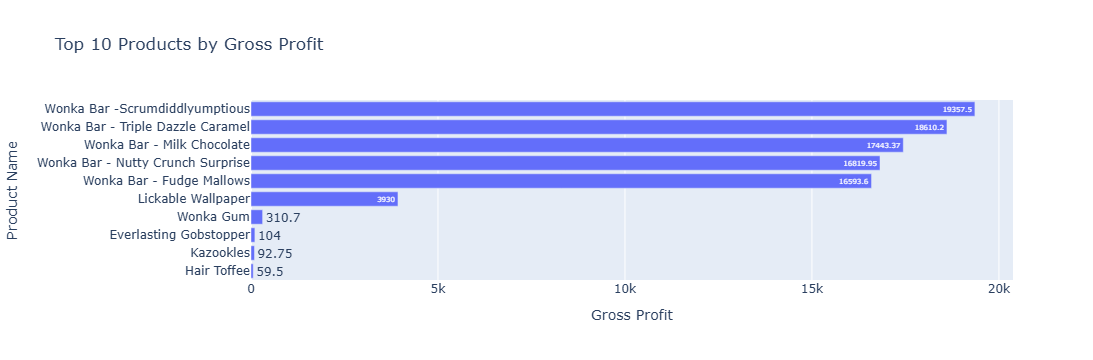

In [69]:
top_profit = product_profitability.nlargest(10, 'Gross Profit')

import plotly.express as px

fig = px.bar(
    top_profit,
    x='Gross Profit',
    y='Product Name',
    orientation='h',
    title='Top 10 Products by Gross Profit',
    text='Gross Profit'
)

fig.update_layout(yaxis={'categoryorder':'total ascending'})
fig.show()

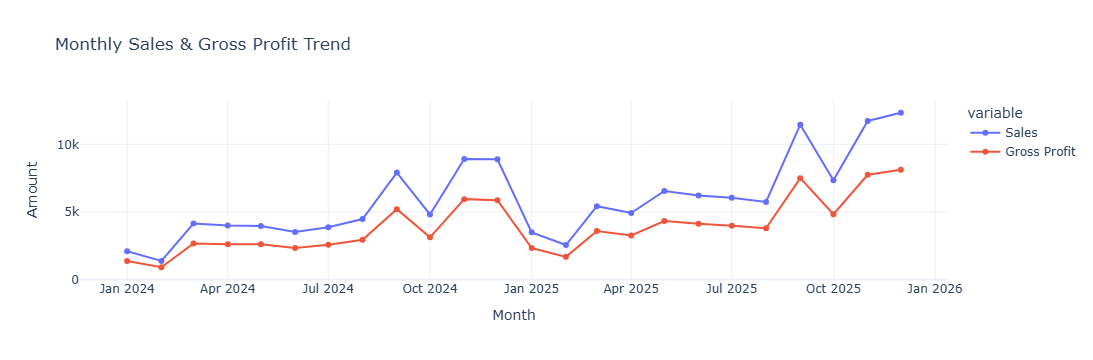

In [71]:
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%d-%m-%Y')
df['Order_Month'] = df['Order Date'].dt.to_period('M').astype(str)

monthly_trend = df.groupby('Order_Month').agg({
    'Sales': 'sum',
    'Gross Profit': 'sum'
}).reset_index()

fig = px.line(
    monthly_trend,
    x='Order_Month',
    y=['Sales', 'Gross Profit'],
    title='Monthly Sales & Gross Profit Trend',
    markers=True
)
fig.update_layout(template='plotly_white', xaxis_title='Month', yaxis_title='Amount')
fig.show()

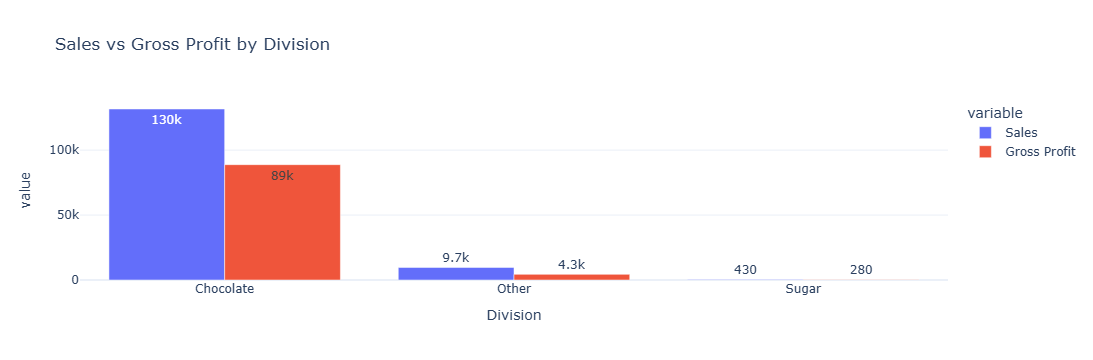

In [73]:
division_compare = df.groupby('Division').agg({
    'Sales': 'sum',
    'Gross Profit': 'sum'
}).reset_index()

fig = px.bar(
    division_compare,
    x='Division',
    y=['Sales', 'Gross Profit'],
    barmode='group',
    title='Sales vs Gross Profit by Division',
    text_auto='.2s'
)
fig.update_layout(template='plotly_white')
fig.show()

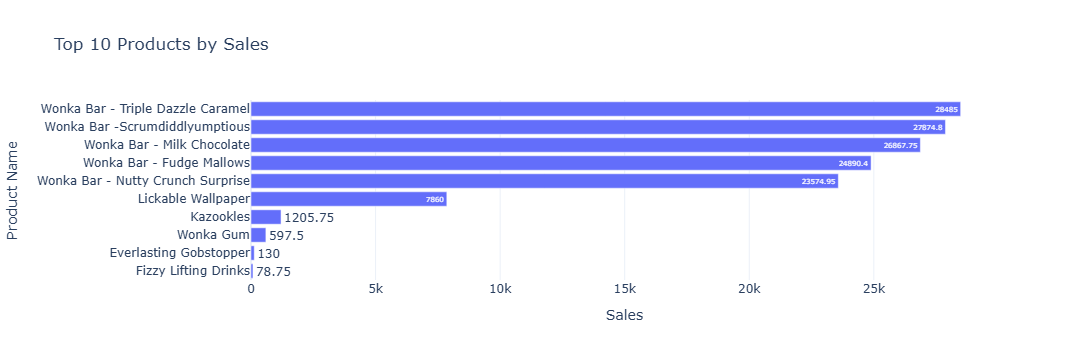

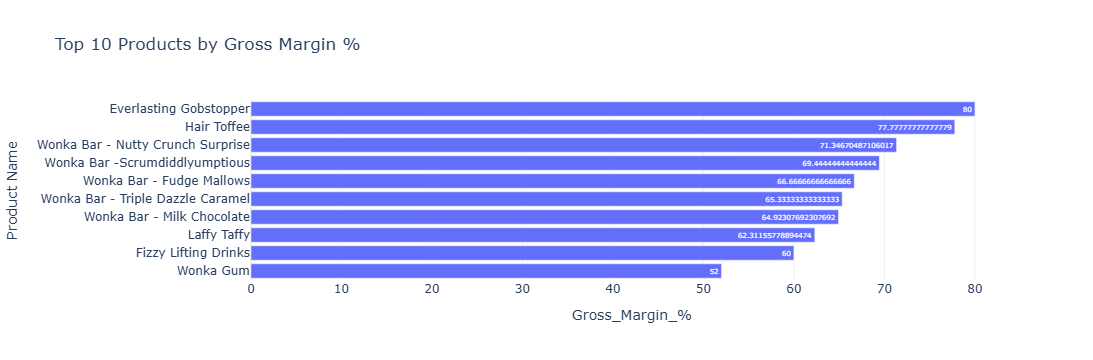

In [75]:
top_sales = product_profitability.nlargest(10, 'Sales')
fig = px.bar(top_sales, x='Sales', y='Product Name', orientation='h',
             title='Top 10 Products by Sales', text='Sales')
fig.update_layout(yaxis={'categoryorder': 'total ascending'}, template='plotly_white')
fig.show()

top_margin = product_profitability.nlargest(10, 'Gross_Margin_%')
fig = px.bar(top_margin, x='Gross_Margin_%', y='Product Name', orientation='h',
             title='Top 10 Products by Gross Margin %', text='Gross_Margin_%')
fig.update_layout(yaxis={'categoryorder': 'total ascending'}, template='plotly_white')
fig.show()

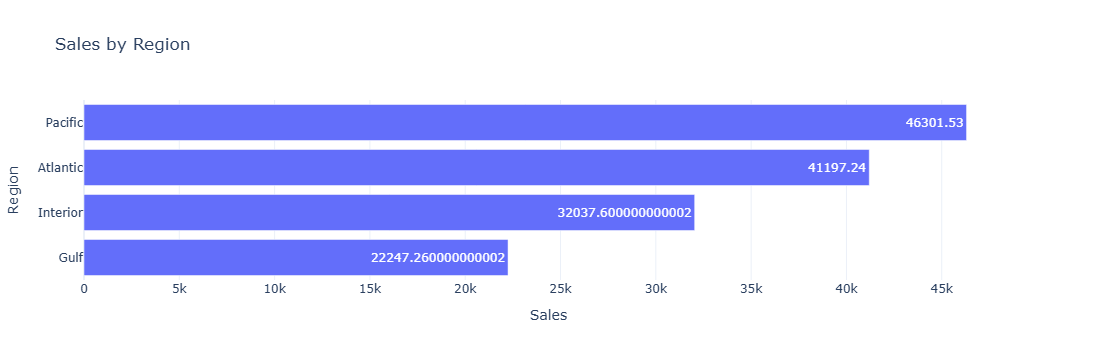

In [77]:
region_sales = df.groupby('Region')['Sales'].sum().reset_index().sort_values('Sales', ascending=True)
fig = px.bar(region_sales, x='Sales', y='Region', orientation='h',
             title='Sales by Region', text='Sales')
fig.update_layout(template='plotly_white')
fig.show()

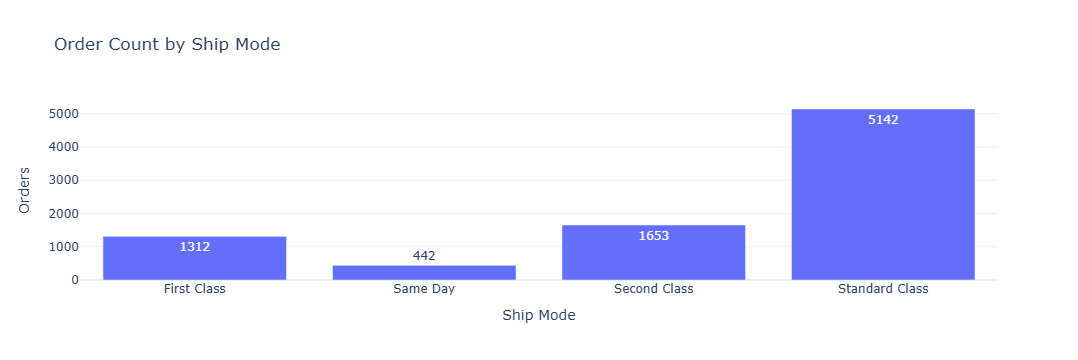

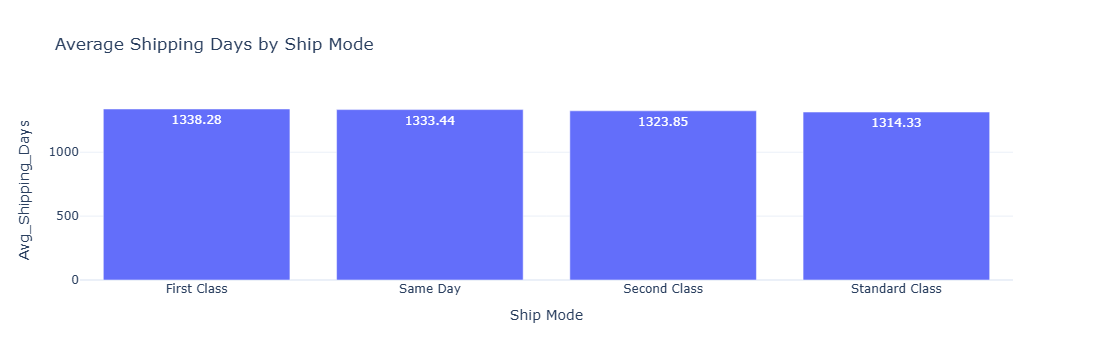

In [79]:
df['Ship Date'] = pd.to_datetime(df['Ship Date'], format='%d-%m-%Y')
df['Shipping_Days'] = (df['Ship Date'] - df['Order Date']).dt.days

ship_summary = df.groupby('Ship Mode').agg(
    Orders=('Order ID', 'nunique'),
    Avg_Shipping_Days=('Shipping_Days', 'mean')
).reset_index()
ship_summary['Avg_Shipping_Days'] = ship_summary['Avg_Shipping_Days'].round(2)

fig = px.bar(ship_summary, x='Ship Mode', y='Orders', title='Order Count by Ship Mode', text='Orders')
fig.update_layout(template='plotly_white')
fig.show()

fig2 = px.bar(ship_summary, x='Ship Mode', y='Avg_Shipping_Days',
              title='Average Shipping Days by Ship Mode', text='Avg_Shipping_Days')
fig2.update_layout(template='plotly_white')
fig2.show()

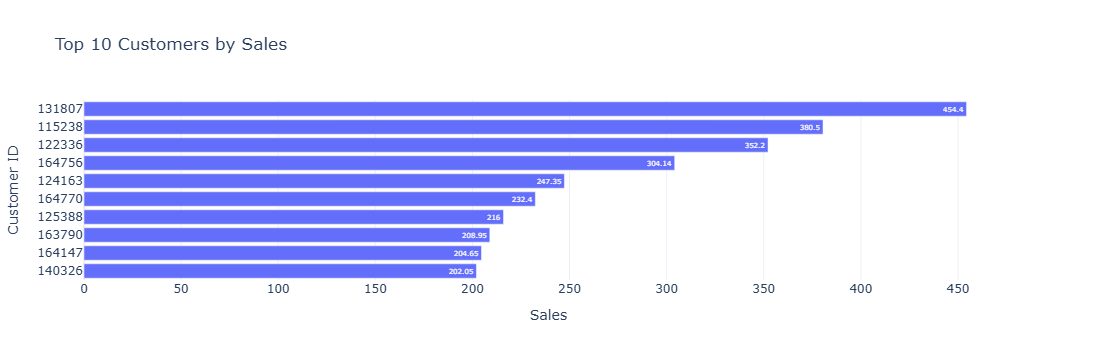

In [80]:
top_customers = df.groupby('Customer ID')['Sales'].sum().reset_index().nlargest(10, 'Sales')
top_customers['Customer ID'] = top_customers['Customer ID'].astype(str)

fig = px.bar(top_customers, x='Sales', y='Customer ID', orientation='h',
             title='Top 10 Customers by Sales', text='Sales')
fig.update_layout(yaxis={'categoryorder': 'total ascending'}, template='plotly_white')
fig.show()


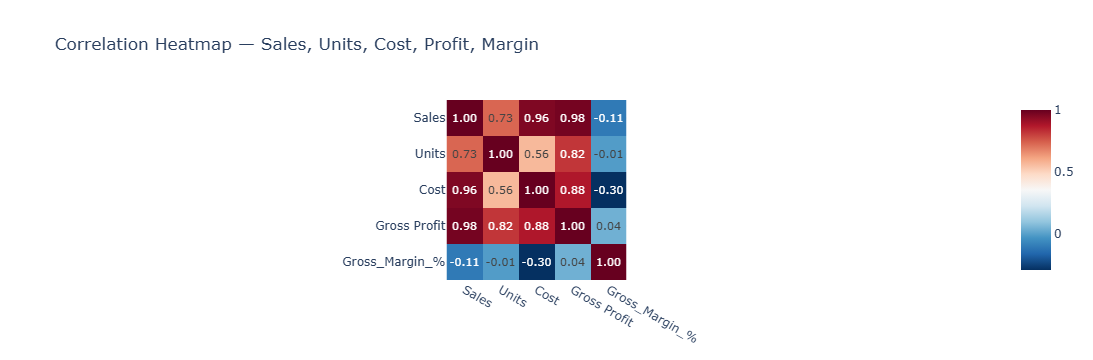

In [82]:
df['Gross_Margin_%'] = (df['Gross Profit'] / df['Sales']) * 100
corr_cols = ['Sales', 'Units', 'Cost', 'Gross Profit', 'Gross_Margin_%']
corr_matrix = df[corr_cols].corr()

fig = px.imshow(
    corr_matrix,
    text_auto='.2f',
    color_continuous_scale='RdBu_r',
    title='Correlation Heatmap — Sales, Units, Cost, Profit, Margin'
)
fig.update_layout(template='plotly_white')
fig.show()

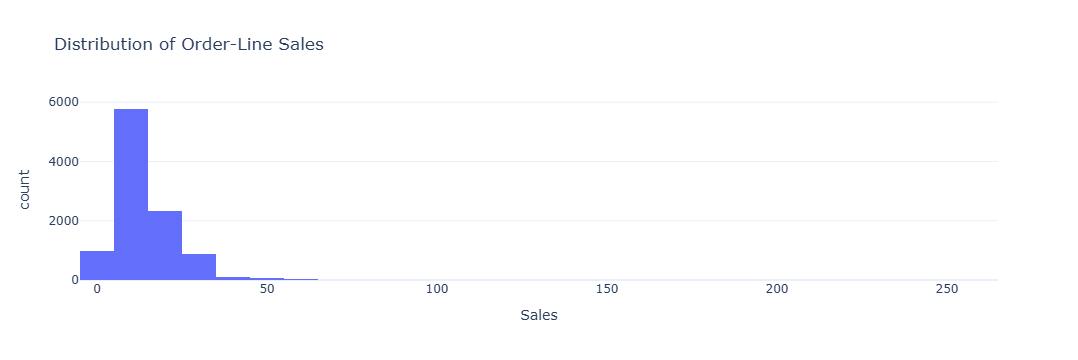

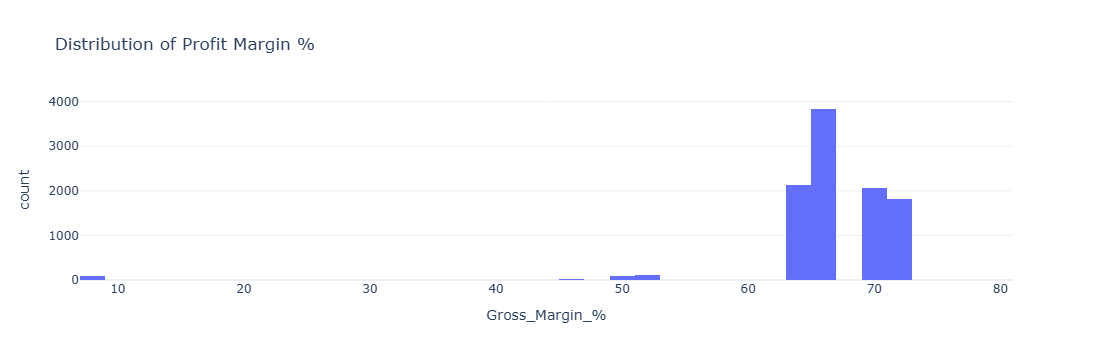

In [84]:
fig = px.histogram(df, x='Sales', nbins=40, title='Distribution of Order-Line Sales')
fig.update_layout(template='plotly_white')
fig.show()

fig2 = px.histogram(df, x='Gross_Margin_%', nbins=40, title='Distribution of Profit Margin %')
fig2.update_layout(template='plotly_white')
fig2.show()